--- 1. ARQUIVO CSV CARREGADO COM SUCESSO ---
Total de registros: 15

--- 2. CONTAGEM DE CONSULTAS POR CLASSE ---
risco
baixo       5
moderado    5
alto        5
Name: count, dtype: int64 

--- 3. COMPRIMENTO MÉDIO DAS CONSULTAS ---
Média geral de caracteres: 133.33
Média geral de palavras: 22.00

Média por classe (palavras):
risco
alto        24.2
baixo       19.0
moderado    22.8
Name: comprimento_palavras, dtype: float64 

--- 4. PALAVRAS MAIS FREQUENTES POR CLASSE ---
Classe [baixo]: [('quais', 2), ('são', 2), ('diminuir', 2), ('algumas', 1), ('dicas', 1)]
Classe [moderado]: [('mês', 2), ('frequentes', 2), ('excessiva', 2), ('dia', 2), ('devo', 2)]
Classe [alto]: [('tendo', 2), ('sofrendo', 2), ('tão', 2), ('perdi', 2), ('sinto', 2)]




/tmp/ipykernel_3405/950775628.py:218: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_3405/950775628.py:226: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_3405/950775628.py:226: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3405/950775628.py:240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


--- 5. GRÁFICOS GERADOS ---
Os gráficos foram salvos no arquivo 'graficos_analise_dataset.png'.

--- 6. AMOSTRA DE 5 EXEMPLOS POR CATEGORIA ---

--- Categoria: BAIXO ---
[Q001] Quais são algumas dicas simples para organizar melhor minha rotina de estudos e diminuir a ansiedade durante a semana de provas?
[Q002] Como posso estabelecer limites saudáveis de trabalho para evitar o esgotamento mental e a fadiga criativa?
[Q003] Quais são os benefícios comprovados da prática de mindfulness e meditação de 10 minutos por dia para a concentração?
[Q004] Existe alguma técnica de respiração rápida para ajudar a relaxar e diminuir o nervosismo antes de uma reunião importante?
[Q005] Como o exercício físico regular e caminhadas ao ar livre ajudam a melhorar o humor e a qualidade do sono?

--- Categoria: MODERADO ---
[Q006] Estou me sentindo excessivamente exausta, irritada e sem motivação para trabalhar há mais de um mês, mesmo dormindo bem. O que pode ser?
[Q007] Tenho sentido crises frequentes de

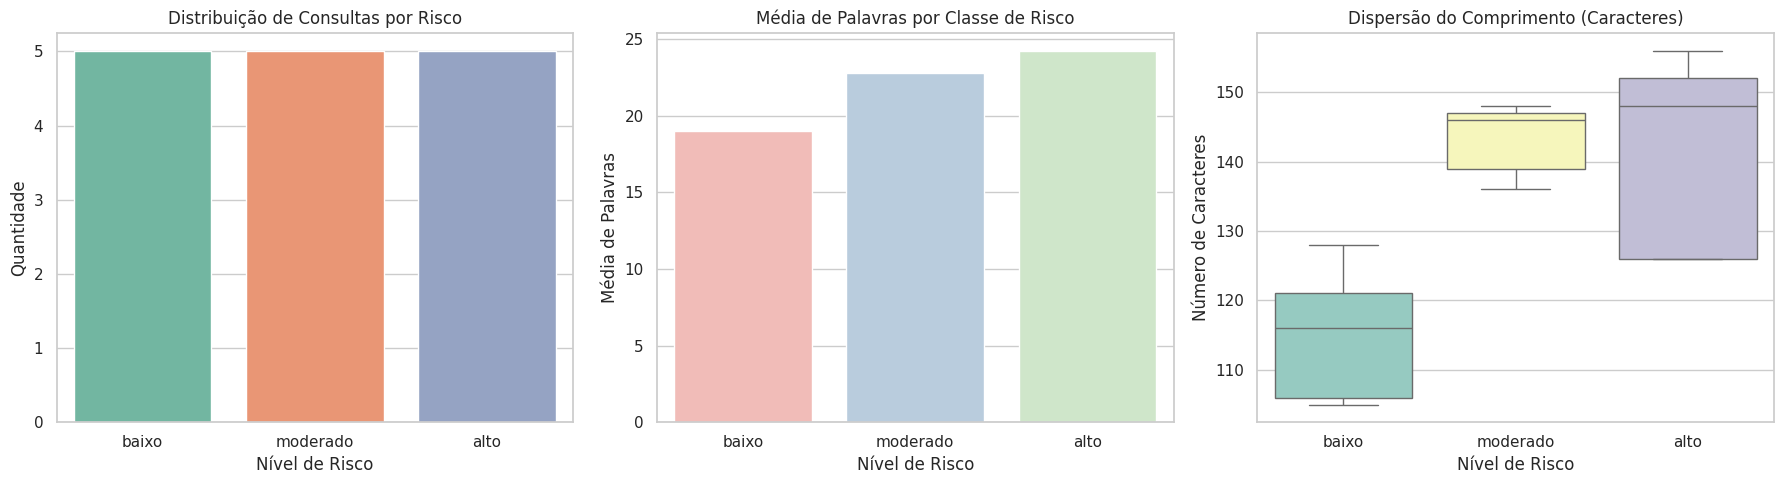

In [1]:
from collections import Counter
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
try:
  df = pd.read_csv("consultas_v01.csv")
except FileNotFoundError:
  data = {
      "id": [f"Q{str(i).zfill(3)}" for i in range(1, 16)],
      "consulta": [
          (
              "Quais são algumas dicas simples para organizar melhor minha"
              " rotina de estudos e diminuir a ansiedade durante a semana de"
              " provas?"
          ),
          (
              "Como posso estabelecer limites saudáveis de trabalho para"
              " evitar o esgotamento mental e a fadiga criativa?"
          ),
          (
              "Quais são os benefícios comprovados da prática de mindfulness e"
              " meditação de 10 minutos por dia para a concentração?"
          ),
          (
              "Existe alguma técnica de respiração rápida para ajudar a"
              " relaxar e diminuir o nervosismo antes de uma reunião"
              " importante?"
          ),
          (
              "Como o exercício físico regular e caminhadas ao ar livre"
              " ajudam a melhorar o humor e a qualidade do sono?"
          ),
          (
              "Estou me sentindo excessivamente exausta, irritada e sem"
              " motivação para trabalhar há mais de um mês, mesmo dormindo"
              " bem. O que pode ser?"
          ),
          (
              "Tenho sentido crises frequentes de preocupação excessiva com o"
              " futuro que estão me impedindo de focar nas tarefas do dia a"
              " dia. Devo procurar ajuda?"
          ),
          (
              "Sinto uma tristeza profunda e persistente há várias semanas,"
              " acompanhada de apatia por coisas que antes eu gostava de"
              " fazer. O que devo investigar?"
          ),
          (
              "Estou enfrentando problemas graves de insônia há quase um mês"
              " porque fico remoçando preocupações financeiras na hora de"
              " dormir. Como lidar?"
          ),
          (
              "Sinto um sentimento constante de inadequação e cobrança"
              " excessiva comigo mesma que está gerando episódios frequentes de"
              " choro sem motivo aparente."
          ),
          (
              "Estou tendo uma crise de pânico paralisante, com falta de ar"
              " extrema, sensação iminente de que vou morrer e meu coração"
              " disparou de um jeito assustador."
          ),
          (
              "Estive sofrendo de uma insônia e angústia tão severas nos"
              " últimos dias que perdi totalmente o contato com a realidade e"
              " estou ouvindo vozes que não existem."
          ),
          (
              "Estou passando por um episódio de despersonalização tão forte"
              " que sinto que meu corpo não é meu e perdi completamente o"
              " controle das minhas reações."
          ),
          (
              "Estou sofrendo de um colapso emocional agudo após um trauma"
              " recente, tremendo sem parar, incapaz de falar ou me mover de"
              " casa."
          ),
          (
              "Estou tendo pensamentos intensos e imediatos de tirar minha"
              " própria vida e sinto que não consigo mais resistir a essa"
              " vontade."
          ),
      ],
      "risco": [
          "baixo",
          "baixo",
          "baixo",
          "baixo",
          "baixo",
          "moderado",
          "moderado",
          "moderado",
          "moderado",
          "moderado",
          "alto",
          "alto",
          "alto",
          "alto",
          "alto",
      ],
      "justificativa": ["Justificativa padrão"] * 15,
      "comportamento esperado": ["Comportamento padrão"] * 15,
      "tipo de fonte desejável": ["Fonte padrão"] * 15,
  }
  df = pd.DataFrame(data)

print("--- 1. ARQUIVO CSV CARREGADO COM SUCESSO ---")
print(f"Total de registros: {len(df)}\n")

# 2. Contar o número de consultas por classe
contagem_classes = df["risco"].value_counts()
print("--- 2. CONTAGEM DE CONSULTAS POR CLASSE ---")
print(contagem_classes, "\n")

# 3. Calcular o comprimento médio das consultas (em caracteres e palavras)
df["comprimento_caracteres"] = df["consulta"].apply(len)
df["comprimento_palavras"] = df["consulta"].apply(lambda x: len(x.split()))

media_geral_caracteres = df["comprimento_caracteres"].mean()
media_geral_palavras = df["comprimento_palavras"].mean()

print("--- 3. COMPRIMENTO MÉDIO DAS CONSULTAS ---")
print(f"Média geral de caracteres: {media_geral_caracteres:.2f}")
print(f"Média geral de palavras: {media_geral_palavras:.2f}\n")

print("Média por classe (palavras):")
print(df.groupby("risco")["comprimento_palavras"].mean(), "\n")

# 4. Identificar as palavras mais frequentes em cada classe (removendo stop words básicas em português)
stop_words = {
    "de",
    "a",
    "o",
    "que",
    "e",
    "do",
    "da",
    "em",
    "um",
    "para",
    "é",
    "com",
    "não",
    "uma",
    "os",
    "no",
    "se",
    "na",
    "por",
    "mais",
    "as",
    "dos",
    "como",
    "mas",
    "foi",
    "ao",
    "ele",
    "das",
    "tem",
    "seu",
    "sua",
    "ou",
    "ser",
    "quando",
    "muito",
    "há",
    "nos",
    "já",
    "está",
    "eu",
    "também",
    "só",
    "pelo",
    "pela",
    "até",
    "isso",
    "ela",
    "entre",
    "depois",
    "sem",
    "mesmo",
    "suas",
    "também",
    "sendo",
    "sobre",
    "meu",
    "minha",
    "tenho",
    "estou",
}


def extrair_palavras_frequentes(texto_serie, n=5):
  texto_completo = " ".join(texto_serie).lower()
  # Remove pontuações e números
  palavras = re.findall(r"\b[a-záéíóúçãõâêô]+\b", texto_completo)
  palavras_filtradas = [p for p in palavras if p not in stop_words and len(p) > 2]
  return Counter(palavras_filtradas).most_common(n)


print("--- 4. PALAVRAS MAIS FREQUENTES POR CLASSE ---")
for classe in ["baixo", "moderado", "alto"]:
  subset = df[df["risco"] == classe]["consulta"]
  mais_freq = extrair_palavras_frequentes(subset, n=5)
  print(f"Classe [{classe}]: {mais_freq}")
print("\n")

# 5. Gerar pelo menos 3 gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Contagem por Classe
sns.countplot(
    data=df, x="risco", order=["baixo", "moderado", "alto"], ax=axes[0], palette="Set2"
)
axes[0].set_title("Distribuição de Consultas por Risco")
axes[0].set_xlabel("Nível de Risco")
axes[0].set_ylabel("Quantidade")

# Gráfico 2: Comprimento Médio de Palavras por Classe
sns.barplot(
    data=df,
    x="risco",
    y="comprimento_palavras",
    order=["baixo", "moderado", "alto"],
    ax=axes[1],
    palette="Pastel1",
    ci=None,
)
axes[1].set_title("Média de Palavras por Classe de Risco")
axes[1].set_xlabel("Nível de Risco")
axes[1].set_ylabel("Média de Palavras")

# Gráfico 3: Distribuição de Caracteres por Risco (Boxplot)
sns.boxplot(
    data=df,
    x="risco",
    y="comprimento_caracteres",
    order=["baixo", "moderado", "alto"],
    ax=axes[2],
    palette="Set3",
)
axes[2].set_title("Dispersão do Comprimento (Caracteres)")
axes[2].set_xlabel("Nível de Risco")
axes[2].set_ylabel("Número de Caracteres")

plt.tight_layout()
plt.savefig("graficos_analise_dataset.png")
print(
    "--- 5. GRÁFICOS GERADOS ---"
)
print("Os gráficos foram salvos no arquivo 'graficos_analise_dataset.png'.\n")

# 6. Mostrar 5 exemplos de cada categoria
print("--- 6. AMOSTRA DE 5 EXEMPLOS POR CATEGORIA ---")
for classe in ["baixo", "moderado", "alto"]:
  print(f"\n--- Categoria: {classe.upper()} ---")
  amostra = df[df["risco"] == classe].head(5)
  for idx, row in amostra.iterrows():
    print(f"[{row['id']}] {row['consulta']}")
print("\n")

# 7. Destacar e comentar os 5 casos ambíguos selecionados
print("--- 7. DESTAQUE DOS 5 CASOS AMBÍGUOS ---")
ambiguos_ids = ["Q006", "Q007", "Q008", "Q009", "Q010"]
for q_id in ambiguos_ids:
  row = df[df["id"] == q_id].iloc[0]
  print(f"ID: {row['id']} | Rótulo: {row['risco']}")
  print(f"Consulta: {row['consulta']}")
  print(
      "Comentário de Ambiguidade: Textos com adjetivos subjetivos ('exaustão',"
      " 'preocupação excessiva', 'tristeza profunda') dependem fortemente da"
      " frequência e do impacto funcional real na vida do utilizador, gerando"
      " fronteiras difusas entre moderado e alto/baixo risco.\n"
  )

print("--- 8. CONCLUSÃO SOBRE CLASSIFICAÇÃO AUTOMÁTICA ---")
conclusao_texto = """
Conclusão:
- O que parece FÁCIL para modelos automáticos (como RAG ou clasificadores baseados em regras/embeddings):
  A deteção de palavras-chave extremas e termos explícitos de emergência (ex: 'tirar minha própria vida', 'ouvindo vozes', 'crise de pânico paralisante') ou perguntas puramente conceituais e educativas ('O que é...', 'Quais dicas...').
- O que parece DIFÍCIL para modelos automáticos:
  A interpretação de nuances subjetivas de sofrimento emocional ('exaustão', 'tristeza profunda', 'preocupação excessiva'), onde a gravidade não reside apenas nas palavras isoladas, mas sim na cronicidade temporal, no contexto implícito e no nível de incapacitação funcional do utilizador.
"""
print(conclusao_texto)